In [1]:
# ensure classes imported from .py files are dynamically updated
%load_ext autoreload
%autoreload 2

# plot matplots nicely
%matplotlib inline  

In [ ]:
from stericheight.data_handler import *
from stericheight.steric_height import *
from stericheight.plotting_fns import PlottingFns
pfns = PlottingFns()

In [4]:
import gsw
import cmocean
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

ARGO = '/nfs/b0133/eejco/data/ARGO/DataSelection_a0ad0869-68c3-4b7d-af4c-9c010ab6e378/'

In [5]:
sla = SLA(deg=0.25).da
sice = xr.open_dataset('../data/NSIDC/sice_processed.nc')
sice = sice.__xarray_dataarray_variable__
elevation_ = GEBCO(coarsen_factor=1).ds.elevation


In [6]:
def sanom(da):
    return da.groupby('time.month') - da.groupby('time.month').mean()

In [7]:
extent =[138,147,-67,-65]
elevation = elevation_.sel(latitude = slice(extent[2], extent[3]), longitude = slice(extent[0],extent[1]))


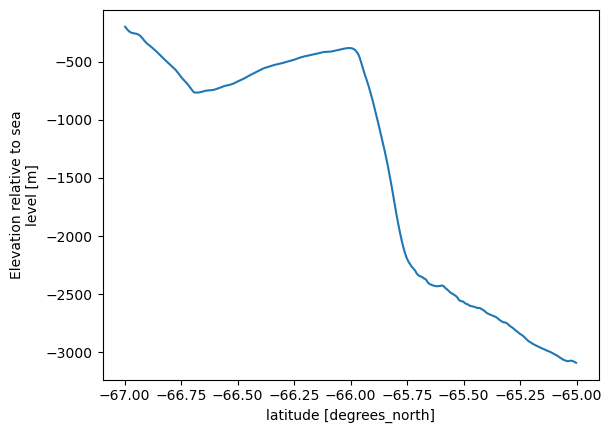

In [8]:
elevation.sel(longitude=slice(143,145)).mean('longitude').plot()

In [9]:
meop_mertz=MEOP(extent=extent)
#df1=meop_mertz.load_profiles()

In [10]:
meop_mertz.load_profiles_for_spira()

 54%|█████▎    | 45/84 [00:28<00:21,  1.78it/s]

skipping dodgy profile ct128-700BAT-12


 58%|█████▊    | 49/84 [00:28<00:10,  3.30it/s]

skipping dodgy profile wd15-970BAT-18


100%|██████████| 84/84 [00:50<00:00,  1.66it/s]


In [11]:
meop_mertz.ds['elev']=elevation.interp({'latitude':meop_mertz.ds.lat,'longitude':meop_mertz.ds.lon})

In [12]:
#find seals which travel a decent (>1 degree) meridional distance
mdlmax = meop_mertz.ds.reset_coords().groupby('profile_code').max().lat
mdlmin = meop_mertz.ds.reset_coords().groupby('profile_code').min().lat
mdemax = meop_mertz.ds.reset_coords().groupby('profile_code').max().elev
mdemin= meop_mertz.ds.reset_coords().groupby('profile_code').min().elev

longg = mdlmax.profile_code.where(((mdlmax - mdlmin) > 0.6) & ((mdemax - mdemin) > 800), drop=True)

/home/users/eejco/miniforge3/envs/nemo-env3/lib/python3.14/site-packages/xarray/structure/concat.py:674: UserWarning: No index created for dimension profile_code because variable profile_code is not a coordinate. To create an index for profile_code, please first call `.set_coords('profile_code')` on this object.
  ds.expand_dims(dim_name, create_index_for_new_dim=create_index_for_new_dim)
/home/users/eejco/miniforge3/envs/nemo-env3/lib/python3.14/site-packages/xarray/structure/concat.py:674: UserWarning: No index created for dimension profile_code because variable profile_code is not a coordinate. To create an index for profile_code, please first call `.set_coords('profile_code')` on this object.
  ds.expand_dims(dim_name, create_index_for_new_dim=create_index_for_new_dim)
/home/users/eejco/miniforge3/envs/nemo-env3/lib/python3.14/site-packages/xarray/structure/concat.py:674: UserWarning: No index created for dimension profile_code because variable profile_code is not a coordinate. To 

In [13]:
longg

<xarray.DataArray 'profile_code' (profile_code: 10)> Size: 80B
array(['ct111-665-13', 'ct64-M052-09', 'ct84-744-12', 'ft33-791-22',
       'wd10-681-17', 'wd12-144-19', 'wd12-145-19', 'wd20-546-19',
       'wd3-CTD2-07', 'wd3-CTD3-07'], dtype=object)
Coordinates:
  * profile_code  (profile_code) object 80B 'ct111-665-13' ... 'wd3-CTD3-07'

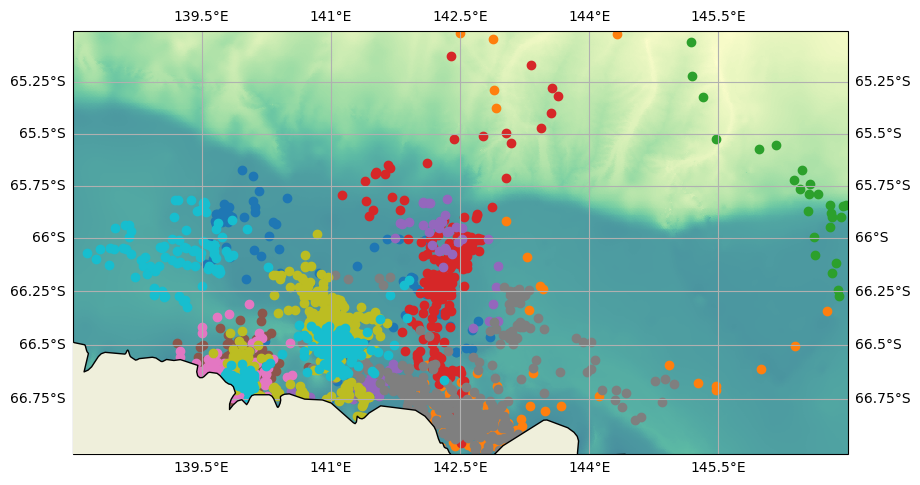

In [14]:
fig,ax=plt.subplots(figsize=(10,8),subplot_kw={'projection':ccrs.Mercator()})
pfns.sp(ax,elevation,extent=extent,cmap=cmocean.cm.deep,land_zorder=3)
for platform in longg:
    dff = meop_mertz.ds.where(meop_mertz.ds.profile_code == platform,drop=True)
    ax.scatter(dff.lon,dff.lat,transform=ccrs.PlateCarree(),label=platform.item())
#ax.legend()

In [15]:
ds = meop_mertz.ds
ds['asal'] = gsw.conversions.SA_from_SP(ds.psal,ds.pres,145,ds.lat)
ds['ctemp'] = gsw.conversions.CT_from_t(ds.asal,ds.temp,ds.pres)
ds['rho'] = gsw.density.rho(ds.asal,ds.ctemp,ds.pres)
ds['sigma0'] = gsw.density.sigma0(ds.asal,ds.ctemp)
ds['month'] = ds.time.dt.month

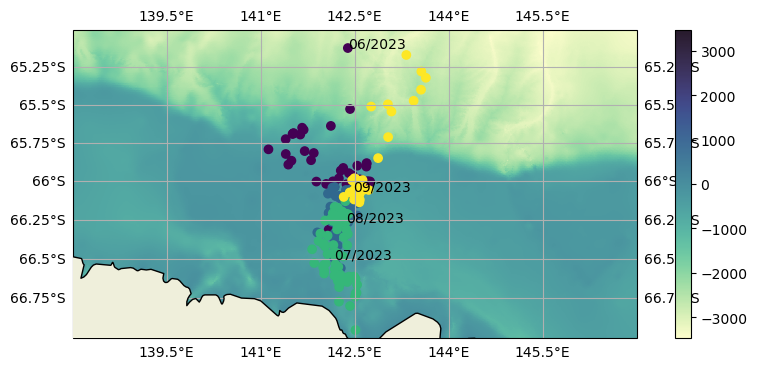

In [24]:
pc = 'ft33-791-22'#'ct84-744-12'#'ct64-M052-09'#'ft33-791-22'
dspc = ds.where(ds.profile_code == pc,drop=True)
fig,ax=plt.subplots(figsize=(10,4),subplot_kw={'projection':ccrs.Mercator()})
im=pfns.sp(ax,elevation,extent=extent,cmap=cmocean.cm.deep)
ax.scatter(dspc.lon,dspc.lat,c=dspc.month,transform=ccrs.PlateCarree(),label=platform.item())
for m in np.unique(dspc.month):
    eg = dspc.where(dspc.month==m,drop=True).isel(time=0)
    tstr = eg.time.dt.strftime("%m/%Y").item()
    ax.text(eg.lon,eg.lat,tstr,transform=ccrs.PlateCarree())
plt.colorbar(im)


In [25]:
dsm = dspc.where(dspc.month == 9,drop=True)
dsml = dsm.swap_dims({'time':'lat'}).sortby('lat')
keep = ~(np.isnan(dsml.sigma0))
x=xr.broadcast(dsml.lat,dsml.pres)[0].where(keep,drop=True).to_numpy().flatten()
y=xr.broadcast(dsml.lat,dsml.pres)[1].where(keep,drop=True).to_numpy().flatten()

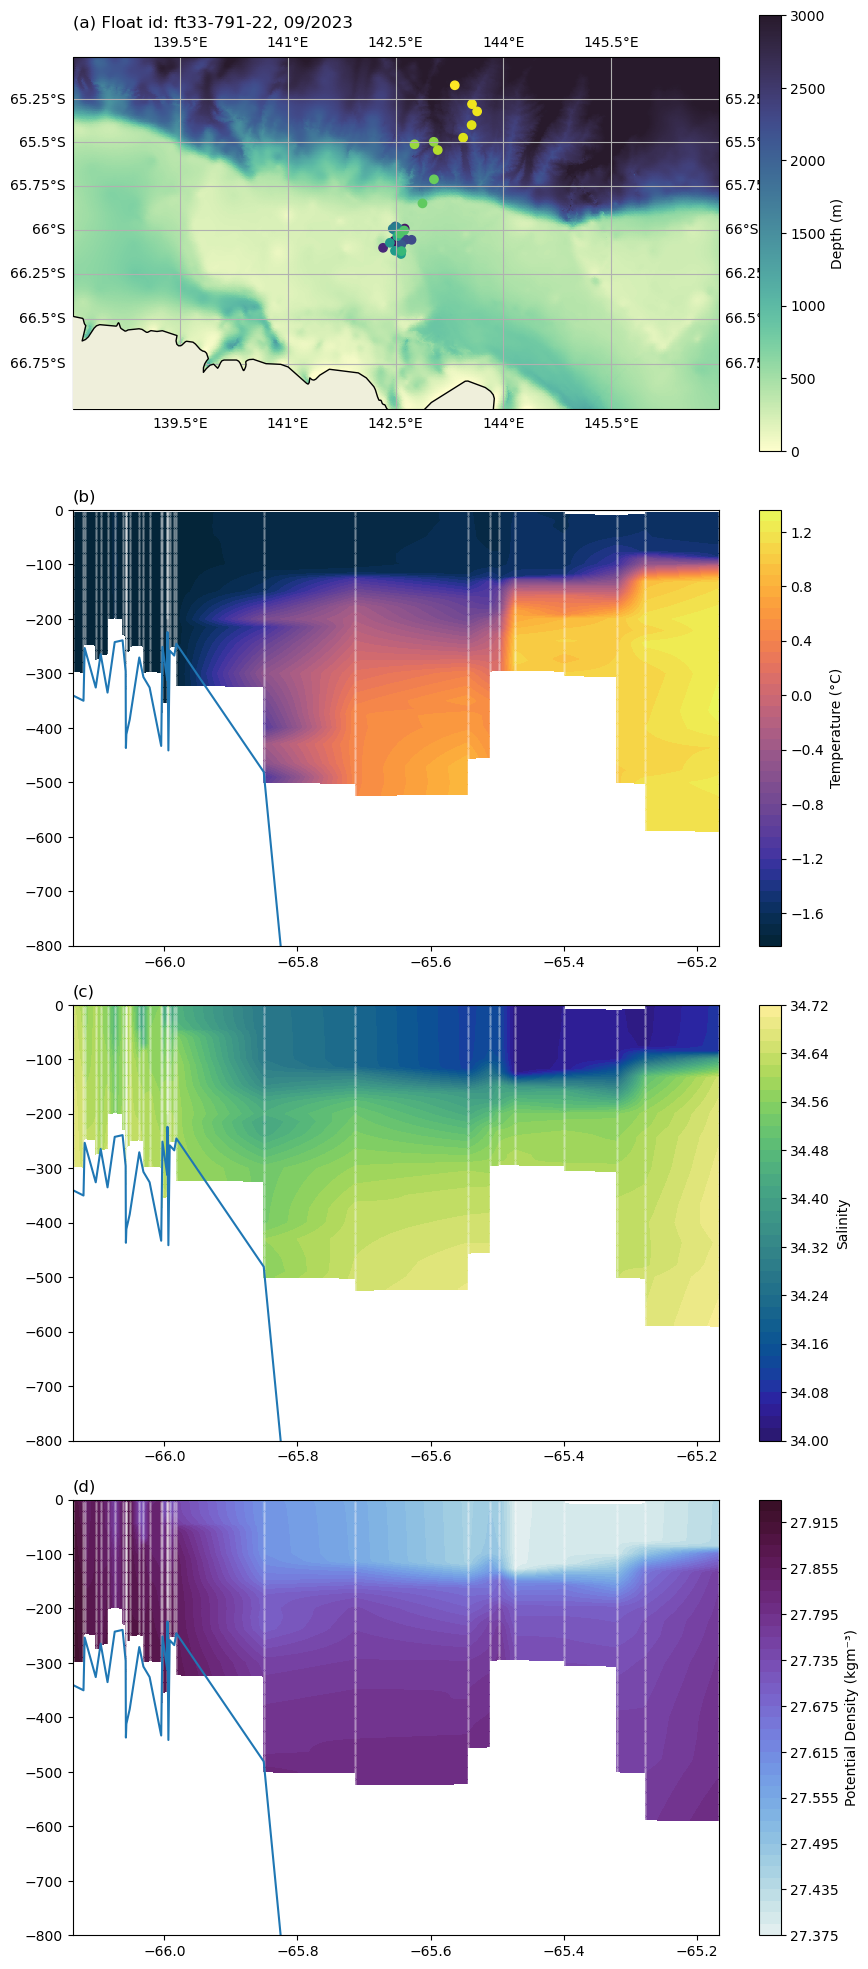

In [26]:

fig = plt.figure(figsize=(9,20))
gs = fig.add_gridspec(4,1)

et = elevation.interp({'latitude':dsml.lat,'longitude':dsml.lon})
minz = -800
levels = 40

ax = fig.add_subplot(gs[0, 0],projection=ccrs.Mercator())
im=pfns.sp(ax,-elevation,extent=extent,cmap=cmocean.cm.deep,land_zorder=3,vmin=0,vmax=3000)
ax.scatter(dsm.lon,dsm.lat,c=dsm.time,transform=ccrs.PlateCarree(),label=platform.item())
c=plt.colorbar(im,label='Depth (m)')
ax.set_title('(a) Float id: ' + pc + ', ' + dsm.time[0].dt.strftime("%m/%Y").item(),loc='left')

ax = fig.add_subplot(gs[1,0])
im=ax.contourf(dsml.lat,-dsml.pres,dsml.temp.T,cmap=cmocean.cm.thermal,levels=levels)#np.linspace(-1.8,0,levels),vmin=-1.8,vmax=0)
ax.plot(et.lat,et)
ax.set_ylim(minz,0)
plt.colorbar(im,label='Temperature (°C)')
ax.scatter(x,-y,marker='.',c='w',s=0.1)
ax.set_title('(b)',loc='left')

ax = fig.add_subplot(gs[2, 0])
im=ax.contourf(dsml.lat,-dsml.pres,dsml.psal.T,cmap=cmocean.cm.haline,levels=levels)#,vmin=34.2,vmax=34.7)
ax.plot(et.lat,et)
ax.set_ylim(minz,0)
plt.colorbar(im,label='Salinity')
ax.scatter(x,-y,marker='.',c='w',s=0.1)
ax.set_title('(c)',loc='left')

ax = fig.add_subplot(gs[3,0])
im=ax.contourf(dsml.lat,-dsml.pres,dsml.sigma0.T,cmap=cmocean.cm.dense,levels=levels)#,vmin=27.5,vmax=28)
ax.plot(et.lat,et)
ax.set_ylim(minz,0)
plt.colorbar(im,label='Potential Density (kgm⁻³)')
ax.scatter(x,-y,marker='.',c='w',s=0.1)
ax.set_title('(d)',loc='left')

plt.tight_layout()


In [ ]:
month = 12
# plot all seal trails for